In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd

from src.config import PROCESSED
from src.data import feature_cols

dev = pd.read_csv(PROCESSED / "dev_2v3.csv")
cols = feature_cols(dev)
dev = dev.sort_values(["segment", "chunk"])
names = sorted(dev["segment"].unique())

A = dev[cols].to_numpy(dtype=float).reshape(len(names), 23, 178)    # segments x chunks x samples
A = A - A.mean(axis=2, keepdims=True)
Z = A / np.linalg.norm(A, axis=2, keepdims=True)                    # each chunk scaled to length 1
M = np.einsum("akd,bkd->ab", Z, Z) / 23                             # mean correlation of chunk k of A with chunk k of B
np.fill_diagonal(M, 0)
best = M.max(axis=1)
print("segments whose best partner has mean correlation > 0.8:", round((best > 0.8).mean(), 2))   # expect 0.44
print("segments whose best partner has mean correlation > 0.9:", round((best > 0.9).mean(), 2))   # expect 0.23

i, j = np.unravel_index(M.argmax(), M.shape)
aligned = [Z[i, k] @ Z[j, k] for k in range(23)]
shifted = [Z[i, k] @ Z[j, (k + 3) % 23] for k in range(23)]
print(names[i], names[j], "| same chunk number: r =", round(np.mean(aligned), 2),
      "| chunk k vs k+3: mean |r| =", round(np.mean(np.abs(shifted)), 2))                          # expect 0.98 and 0.17

segments whose best partner has mean correlation > 0.8: 0.57
segments whose best partner has mean correlation > 0.9: 0.3
V1.163 V1.343 | same chunk number: r = 0.99 | chunk k vs k+3: mean |r| = 0.23


## Group all 200 segments (signals only, no labels, no scoring)

In [2]:
from src.config import PROCESSED, SPLITS, N_FOLDS, N_REPEATS
from src.data import load_binary, split_holdout_by_group
from src.groups import similarity_matrix, make_groups
from src.cv import make_group_fold_table

both = load_binary()                                   # all 200 segments of classes 2 and 3
names_all, M_all = similarity_matrix(both, cols)
group_of = make_groups(names_all, M_all)
y_seg = both.groupby("segment")["y"].first().loc[names_all]

sizes = group_of.value_counts()
print("groups:", group_of.nunique(), "| group sizes:", sizes.value_counts().sort_index().to_dict())
print("groups containing both classes:", sum(y_seg[group_of[group_of == g].index].nunique() > 1 for g in sizes.index))

groups: 94 | group sizes: {1: 41, 2: 25, 3: 19, 4: 3, 5: 3, 7: 1, 9: 2}
groups containing both classes: 1


## New hold-out, with an audit

In [3]:
dev_new, hold_new = split_holdout_by_group(both, group_of)
print("dev:", dev_new["segment"].nunique(), dev_new.groupby("segment")["y"].first().value_counts().to_dict())
print("hold-out:", hold_new["segment"].nunique(), hold_new.groupby("segment")["y"].first().value_counts().to_dict())

idx = {n: i for i, n in enumerate(names_all)}
h = [idx[s] for s in hold_new["segment"].unique()]
d = [idx[s] for s in dev_new["segment"].unique()]
print("most similar hold-out/dev pair:", round(M_all[np.ix_(h, d)].max(), 2))

dev: 160 {3: 80, 2: 80}
hold-out: 40 {3: 20, 2: 20}
most similar hold-out/dev pair: 0.67


## New folds, with an audit

In [4]:
table_new = make_group_fold_table(dev_new, group_of)
for r in range(N_REPEATS):
    col = f"repeat_{r}"
    worst = max(M_all[np.ix_([idx[s] for s in table_new["segment"][table_new[col] == k]],
                              [idx[s] for s in table_new["segment"][table_new[col] != k]])].max()
                for k in range(N_FOLDS))
    per_fold = table_new.groupby(col).size()
    print(f"repeat {r}: most similar validation/training pair {worst:.2f} | segments per fold {per_fold.min()}-{per_fold.max()}")

repeat 0: most similar validation/training pair 0.65 | segments per fold 15-18
repeat 1: most similar validation/training pair 0.65 | segments per fold 15-18
repeat 2: most similar validation/training pair 0.65 | segments per fold 15-18
repeat 3: most similar validation/training pair 0.65 | segments per fold 15-18
repeat 4: most similar validation/training pair 0.65 | segments per fold 15-18


## Save (skipped if the splits already exist)

In [5]:
if (SPLITS / "cv_folds.csv").exists():
    print("splits already exist, not overwriting")
else:
    dev_new.to_csv(PROCESSED / "dev_2v3.csv", index=False)
    hold_new.to_csv(PROCESSED / "holdout_2v3.csv", index=False)
    table_new.to_csv(SPLITS / "cv_folds.csv", index=False)
    pd.DataFrame({"segment": sorted(hold_new["segment"].unique())}).to_csv(SPLITS / "holdout_segments.csv", index=False)
    group_of.rename_axis("segment").reset_index().to_csv(SPLITS / "groups.csv", index=False)

splits already exist, not overwriting


# 06 Near-duplicate segments: finding them and fixing the splits

## What was found
- Many segments are near-copies of each other: the same recording, at the same time, under two segment IDs. 44% of dev segments have a partner with mean aligned correlation above 0.8, and 22% above 0.9.
- Example: V1.733 and V1.963 match chunk by chunk (r = 0.98), but not when chunk numbers are offset (0.17).
- Splitting by segment kept each segment's own chunks together but not its twin, so a twin in training could give away a validation segment's label. Scores in notebooks 04 and 05 were inflated by this.

## The fix
- Segments are grouped as twins if they are more similar than 0.7, or sit in a tight cluster (every pair above 0.4, complete linkage). 200 segments form 94 groups (sizes 1 to 9). One group contains both classes.
- Hold-out and CV folds are made from whole groups. Hold-out: 40 segments (20 per class), 18 groups. Dev: 160 segments (80 per class).
- Audit: the most similar hold-out/dev pair is 0.67, and the most similar validation/training pair in any fold is 0.65, both below 0.7.
- Splits are saved in `splits/` (groups, hold-out, folds). The old splits were overwritten on purpose.

## Caveats
- Similarity is graded, so weaker twins below the thresholds may remain. Scores should be read as upper bounds.
- The hold-out has only 18 groups, so it can only confirm a large effect.
- Folds now hold 15 to 18 segments and are not perfectly balanced, so the headline AUC is the mean of per-fold AUCs.

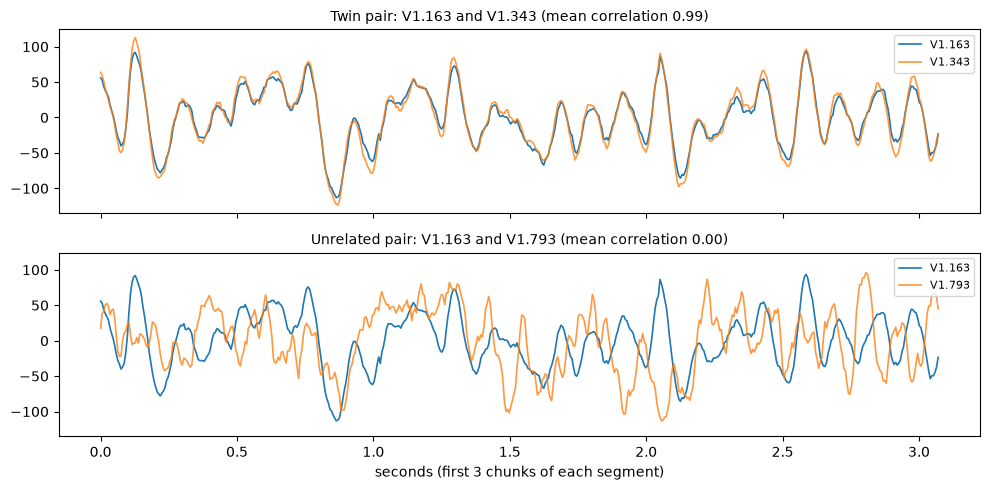

In [6]:
import matplotlib.pyplot as plt
from src.config import FIGURES, SAMPLING_RATE_HZ

others = np.abs(M[i]).copy()
others[i] = 9
k = others.argmin()                                    # a segment unrelated to segment i
n_chunks = 3
t = np.arange(n_chunks * 178) / SAMPLING_RATE_HZ
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True, sharey=True)
for ax, other, title in [(axes[0], j, f"Twin pair: {names[i]} and {names[j]} (mean correlation {M[i, j]:.2f})"),
                         (axes[1], k, f"Unrelated pair: {names[i]} and {names[k]} (mean correlation {M[i, k]:.2f})")]:
    ax.plot(t, A[i, :n_chunks].ravel(), lw=1.2, label=names[i])
    ax.plot(t, A[other, :n_chunks].ravel(), lw=1.2, label=names[other], alpha=0.8)
    ax.set_title(title, fontsize=10)
    ax.legend(loc="upper right", fontsize=8)
axes[-1].set_xlabel("seconds (first 3 chunks of each segment)")
plt.tight_layout()
plt.savefig(FIGURES / "06_twin_pair.png", dpi=150)
plt.show()

In [7]:
same_class = (y_seg.values[:, None] == y_seg.values[None, :])
iu = np.triu_indices(len(names_all), 1)
for thr in (0.7, 0.8, 0.9):
    above = M_all[iu] > thr
    print(f"pairs above {thr}: {above.sum()} | in the same class: {same_class[iu][above].mean():.2f}")

pairs above 0.7: 120 | in the same class: 1.00
pairs above 0.8: 86 | in the same class: 1.00
pairs above 0.9: 37 | in the same class: 1.00
